# **Comparative Analysis of Literary Translations in the Odyssey: Zipf's Law in Depth**

This is a comparative Zipf's Law analysis of six translations spanning roughly the last century: 1919–2018. 

## **Road Map**

### I. Libraries, files, and paths

### II. Zipf's Law Analysis

1. All-in, straightforward model  
    a) TTR Computation  
    b) Shapiro-Wilk test to check for normality  
    c) One-wat ANOVA for overall differences  
    d) Pairwise t-test using Bonferroni coprrection  
    c) Meassuring effect size ussing Cohen's d  

2. Adaptive models  
    a) Mixed-Effects model: author fixed effect / book as random effect  
    b) Standardized TTR:   
    c) Moving-average TTR: translation as temporal change  

3. Supplement models  
    a) Lexical Density   
    b) Diachronic analysis  
    c) Semantic fields:  

### IV. Discussing Results
    

## **I. Libraries, files, and paths**

In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

In [2]:
#### Pandas set-up
import numpy as np
import pandas as pd

In [3]:
#### Visualization
sys.path.append('/Users/debr/English-Homer') 
import matplotlib.pyplot as plt
import seaborn as sns
import bard_visualization as viz # My Vizualization library

Bard viz is on the stage!


In [4]:
# Import my functions
sys.path.append('/Users/debr/English-Homer/functions') 
import e_nlp as e

e enters! »----> use e.<function>

e.g., for pipeline:
		 nlp = e.NLPPipeline(language="english")

Stopwords customized:
  Added: {'seven', 'n', 'three', 'nine', 'ten', "'and", 'eight', 'one', 'six', 'five', 'four', "'", 'two'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {'”', '…', '‘', '’', '-', '—', '\\', '“'}
  Punctuation to be removed: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~—‘’“”…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
#### Cell display options
pd.set_option("display.max_rows", 2000)  # Increase row display
pd.set_option("display.max_colwidth", 200)  # Prevent truncation of long values
pd.set_option("display.precision", 2)  # Display numbers with two decimal places
pd.set_option("display.float_format", "{:.2f}".format)  # Format float numbers
pd.set_option("display.max_columns", None)  # Show all columns
#pd.set_option("display.expand_frame_repr", False)  # Prevent wrapping in DataFrames
pd.set_option("display.width", 1000)  # Prevent wrapping in DataFrames
pd.set_option("colheader_justify", "left")

In [7]:
#### File management
# TO UPDATE
nb_id = "Zipf_Six_Modern"
odysseys = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Paths
output_path = f"/Users/debr/English-Homer/{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_path_plots = f"{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

In [36]:
# Daframe with all the odysseys
dfs = []

for odyssey in odysseys:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df = df[['author', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens']]
df["diff"] = df["num_words"] - df["num_tokens"]
e.check_df(df)

No missing values

df columns: Index(['author', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens', 'diff'], dtype='object') 

Shape: (144, 7)


In [37]:
df.sample(4, random_state=4)

,author,book_num,text,tokens,num_words,num_tokens,diff
128,Green,9,"[Then resourceful Odysseus responded to him, saying:\n, “Alkinoos, lord, most distinguished among all peoples,\n, it is indeed a good thing to listen to such a minstrel\n, as this man is, who rese...","[resourceful, odysseus, responded, saying, alkinoos, lord, distinguished, among, peoples, indeed, good, thing, listen, minstrel, man, resembles, gods, singing, say, greater, fulfillment, pleasure,...",5950,2786,3164
5,AT_Murray,6,"[So here Odysseus slept, overcome by sleep and\n, toil; but Athena went off to the demos and city of\n, the Phaeacians - a people who used to live in the fair town of Hypereia, near\n, the lawless...","[odysseus, slept, overcome, sleep, toil, athena, went, demos, city, phaeacians, people, used, live, fair, town, hypereia, near, lawless, cyclopes, cyclopes, stronger, force, plundered, king, nausi...",3470,1492,1978
61,Lattimore,14,"[But Odysseus himself left the harbor and ascended a rugged\n, path, through wooded country along the heights, where Athene\n, had indicated the noble swineherd, who beyond others\n, cared for the...","[odysseus, left, harbor, ascended, rugged, path, wooded, country, along, heights, athene, indicated, noble, swineherd, beyond, others, cared, house, properties, acquired, noble, odysseus, found, s...",6328,2728,3600
29,Fitzgerald,6,"[Far gone in weariness, in oblivion, \n, the noble and enduring man slept on; \n, but Athena in the night went down the land \n, of the Phaiakians, entering their city. \n, In days gone by, these ...","[far, gone, weariness, oblivion, noble, enduring, man, slept, athena, night, went, land, phaiakians, entering, city, days, gone, men, held, hypereia, country, wide, dancing, grounds, near, overbea...",2907,1454,1453


In [40]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   author      144 non-null    object
 1   book_num    144 non-null    int64 
 2   text        144 non-null    object
 3   tokens      144 non-null    object
 4   num_words   144 non-null    int64 
 5   num_tokens  144 non-null    int64 
 6   diff        144 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 3.3 MB


In [41]:

sys.getsizeof(df) / 1_000_000 # Size in MB

3.500748

In [43]:
print("Memory per column:", df.memory_usage(deep=True) / 1_000_000) # Size in MB
print("Total memory:", df.memory_usage(deep=True).sum() / 1_000_000) # Size in MB

Memory per column: Index        0.00
author       0.01
book_num     0.00
text         0.63
tokens       2.86
num_words    0.00
num_tokens   0.00
diff         0.00
dtype: float64
Total memory: 3.500716


#### 2. **The translators**

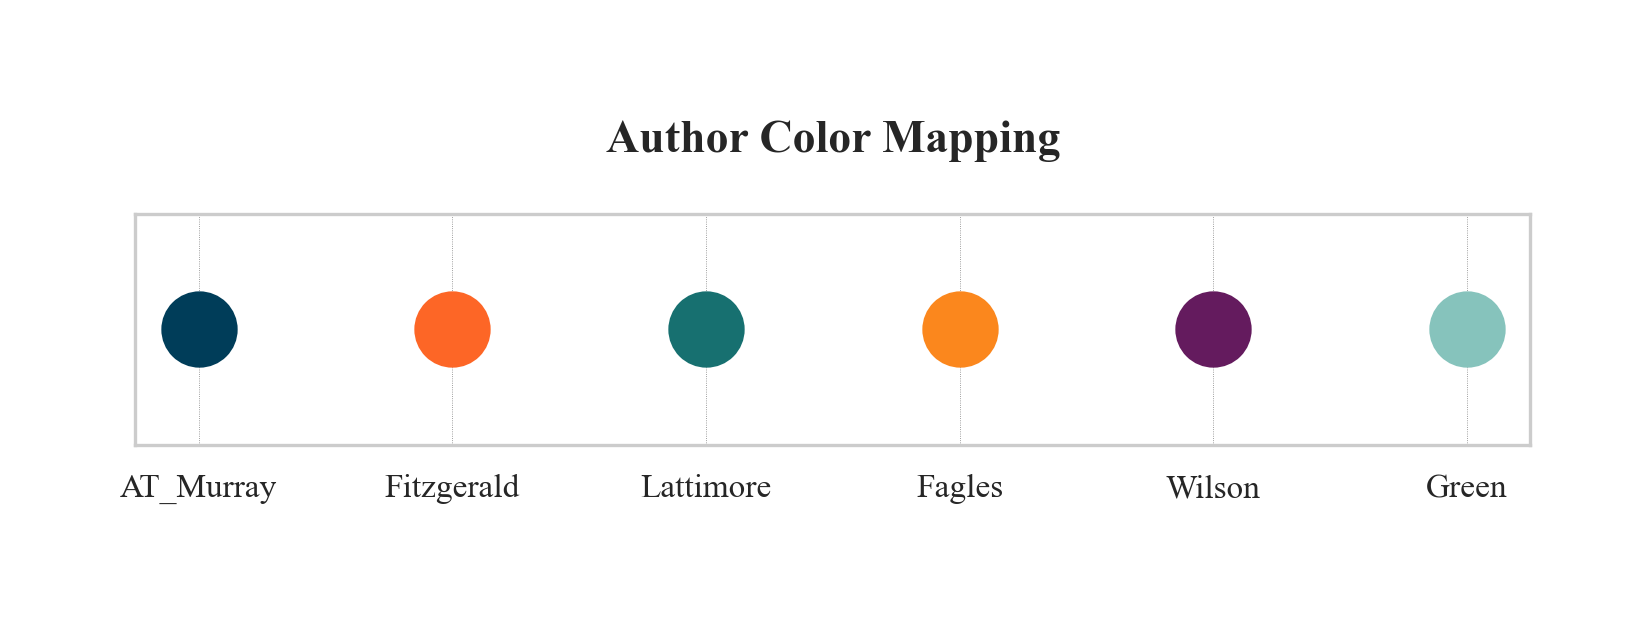

In [44]:
# Create a color mapping for authors
authors = df["author"].unique()
palette = {author: color for author, 
           color in zip(authors, viz.color_palette.values())}

# Plot the color mapping
plt.figure(figsize=(6, 1))

for i, (author, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=300)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Author Color Mapping", fontsize=11)
plt.savefig(f"{output_path_plots}author_color_mapping-{nb_id}.png")
plt.show()

________________________________
## **II. Zipf’s Law Analysis**

### **What and why:** 

Zipf’s Law states that in a large text corpus, the frequency of a word is inversely proportional to its rank in the frequency table. This metric is relevant in comparing translations because it reveals how each translator balances **common vs. rare words**, shedding light on **lexical richness and stylistic choices**. This experiment provides empirical insight into whether a translator’s lexical distribution align with universal linguistic principles.


### **Implications for Translation Studies**

a) **natural linguistic flow:** Strong Zipfian adherence suggests that translators maintain natural language patterns, balancing high-frequency function words with low-frequency content words.  

b) **Poetic stylization:** Deviations may indicate differences in lexical richness, syntactic choices, or stylistic adaptation in translation.
    b) **Philological fidelity:** 'Stylistic' shifts from a natural distribution can also point out a cultural bias or genre requirements that, for epic oral poetry, demand disticnt repetitive and formulaic patterns, epithets, etc.



🔬 **Implementation**

To examine if the translation sample adhere to Zipf’s Law, I'll analyze the relationship between word frequency and rank:

1️⃣ Compute word frequencies for each translation.  
2️⃣ Rank words from most to least frequent.  
3️⃣ Plot word frequency vs. rank on a log-log scale.  

**Zipf’s Law in Translation**

Zipf’s Law states that in any natural language corpus, *the frequency of a word is inversely proportional to its rank:*


$$ f \propto \frac{1}{r} $$

Where:
* f = frequency of the word
* r = rank of the word (1st most frequent, 2nd most frequent, etc.)



In [45]:
# List of authors
authors = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Step 1: Flatten tokens and count word frequencies for each author
freq_dict = {
    author: Counter(
        token for tokens in df[df["author"] == author]["tokens"] for token in tokens
    )
    for author in authors
}

# Step 2: Convert word frequencies into sorted DataFrames with rank
df_zipf_dict = {
    author: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for author, freq in freq_dict.items()
}

# Example: Accessing a specific author’s Zipf DataFrame
df_zipf_dict["AT_Murray"].tail(15).T  # View the top-ranked words for AT_Murray

,3890,3891,3892,3893,3895,3897,3898,3903,3904,3905,3906,3907,3909,3910,6320
word,depends,noiselessly,threes,withies,ensconced,udders,backs,wont,mob,flowery,mead,bubbling,lag,nogood,parties
frequency,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
rank,6307.00,6308.00,6309.00,6310.00,6311.00,6312.00,6313.00,6314.00,6315.00,6316.00,6317.00,6318.00,6319.00,6320.00,6321.00


In [47]:
# Print total number of tokens per translator
for translator in translators:
    total_tokens = sum(freq_dict[translator].values())
    print(f"{translator}: {total_tokens} tokens")

AT_Murray: 51047 tokens
Fitzgerald: 53418 tokens
Lattimore: 61716 tokens
Fagles: 61974 tokens
Wilson: 47705 tokens
Green: 59202 tokens


In [48]:
# Compute min and max ranks across all translators
min_rank = min(df["rank"].min() for df in df_zipf_dict.values())
max_rank = max(df["rank"].max() for df in df_zipf_dict.values())

# Compute min and max frequencies across all translators
min_freq = min(df["frequency"].min() for df in df_zipf_dict.values())
max_freq = max(df["frequency"].max() for df in df_zipf_dict.values())

print(f"Rank range: {min_rank} to {max_rank}")
print(f"Frequency range: {min_freq} to {max_freq}")

Rank range: 1.0 to 8540.0
Frequency range: 1 to 718


In [49]:
print(type(df["tokens"].iloc[0]))  # Check first row's token type
print(df["tokens"].iloc[0])        # Print the actual content

<class 'list'>
['tell', 'muse', 'manysided', 'hero', 'traveled', 'far', 'wide', 'sacked', 'famous', 'town', 'troy', 'many', 'cities', 'visit', 'many', 'people', 'whose', 'customs', 'thinking', 'acquainted', 'many', 'things', 'suffered', 'sea', 'seeking', 'save', 'life', 'achieve', 'safe', 'homecoming', 'companions', 'might', 'could', 'save', 'men', 'perished', 'sheer', 'recklessness', 'eating', 'cattle', 'sungod', 'helios', 'god', 'prevented', 'ever', 'reaching', 'home', 'tell', 'told', 'came', 'things', 'daughter', 'zeus', 'starting', 'whatsoever', 'point', 'choose', 'escaped', 'death', 'battle', 'shipwreck', 'got', 'safely', 'home', 'except', 'odysseus', 'though', 'longing', 'return', 'wife', 'country', 'detained', 'goddess', 'calypso', 'got', 'large', 'cave', 'wanted', 'marry', 'years', 'went', 'came', 'time', 'gods', 'settled', 'go', 'back', 'ithaca', 'even', 'however', 'among', 'people', 'trials', 'yet', 'nevertheless', 'gods', 'begun', 'pity', 'except', 'poseidon', 'still', 'pers